In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 8]

Original image size: 2054x1030
Rescaled image size: 1000x501


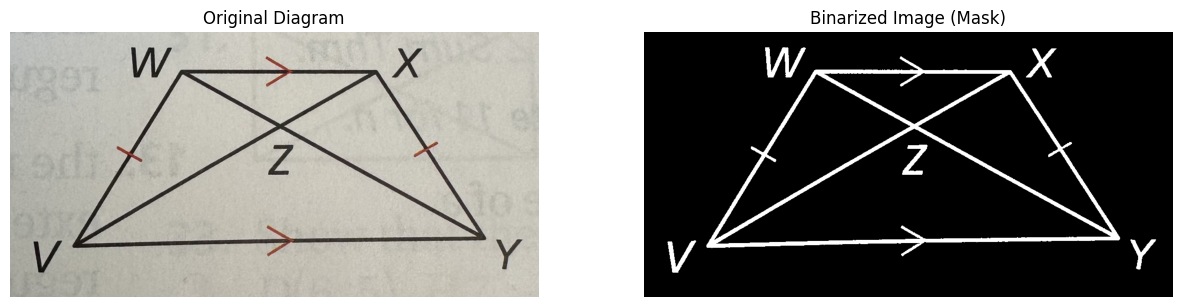

In [2]:
# load image and preprocess
img_bgr = cv2.imread('diagram_sample_image/photo4.jpg')

# scale image so that longest side is 1000 pixels
width, height = img_bgr.shape[1], img_bgr.shape[0]
max_dim = max(height, width)
scale_factor = 1000 / max_dim
img_bgr = cv2.resize(img_bgr, (int(width * scale_factor), int(height * scale_factor)), interpolation=cv2.INTER_AREA)
print(f"Original image size: {width}x{height}")
print(f"Rescaled image size: {img_bgr.shape[1]}x{img_bgr.shape[0]}")

img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
_, img_binary = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)

fig, ax = plt.subplots(1, 2, figsize=(15, 7))
ax[0].imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
ax[0].set_title("Original Diagram")
ax[0].axis('off')

ax[1].imshow(img_binary, cmap='gray')
ax[1].set_title("Binarized Image (Mask)")
ax[1].axis('off')
plt.show()

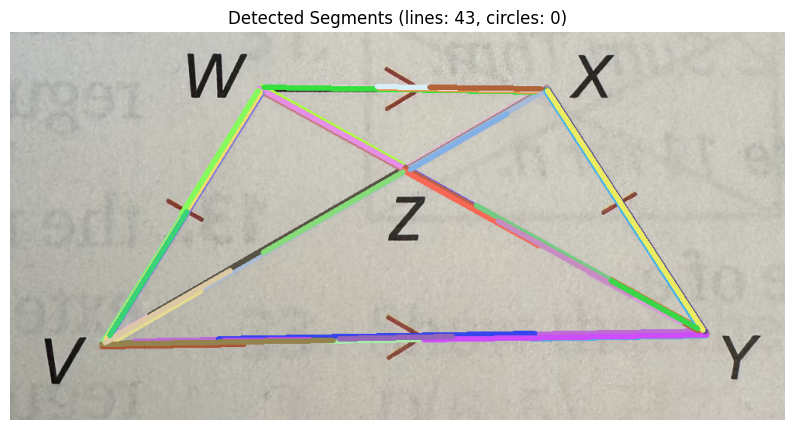

In [3]:
from draw_figures import draw_segments_on_image

lines = cv2.HoughLinesP(img_binary, rho=1, theta=np.pi/180, threshold=100, minLineLength=100, maxLineGap=0)
line_img = img_bgr.copy()

draw_segments_on_image(line_img, lines)


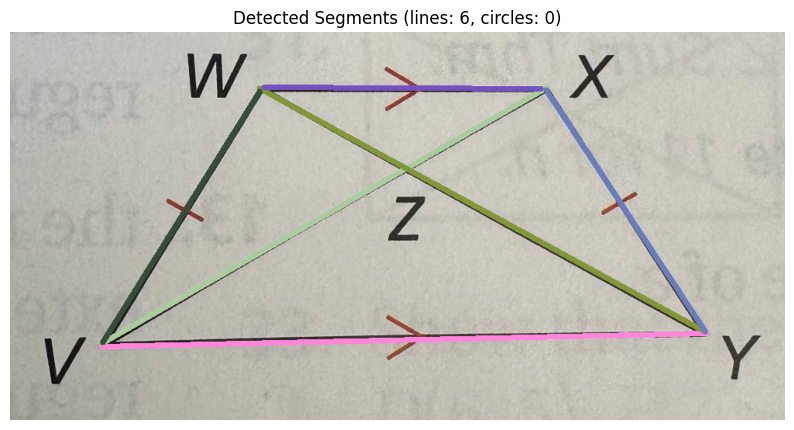

In [4]:
from combine_geometry import combine_lines

combined_lines = combine_lines(lines)
draw_segments_on_image(line_img, combined_lines)

Found 5 valid segment intersection points:


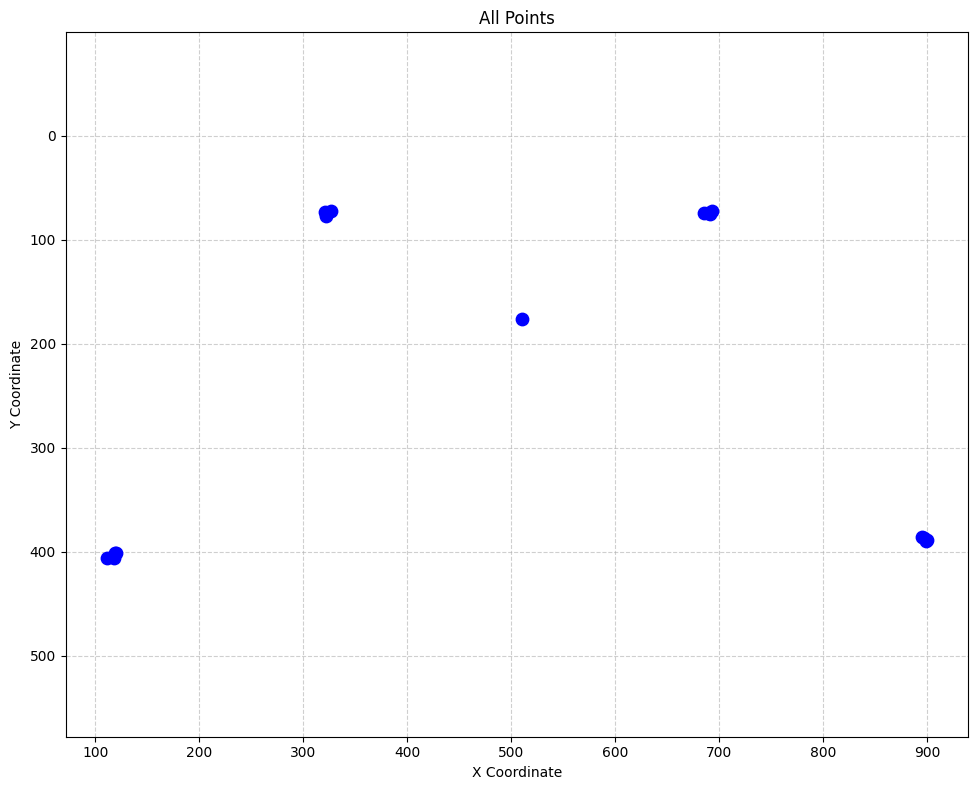

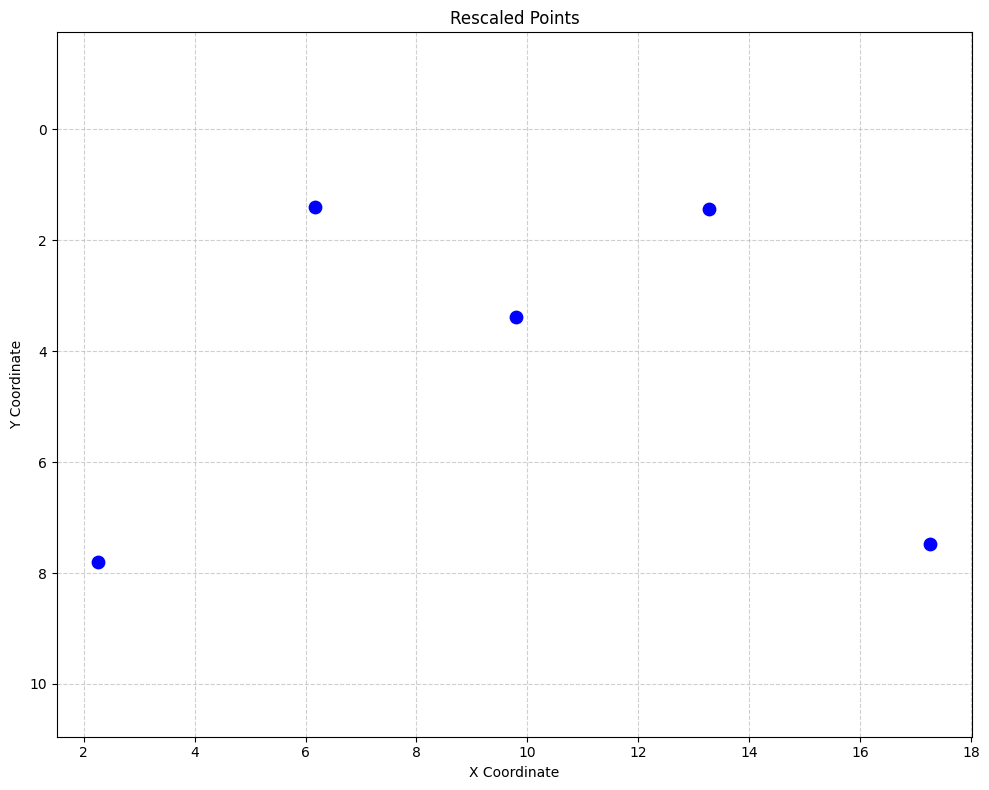

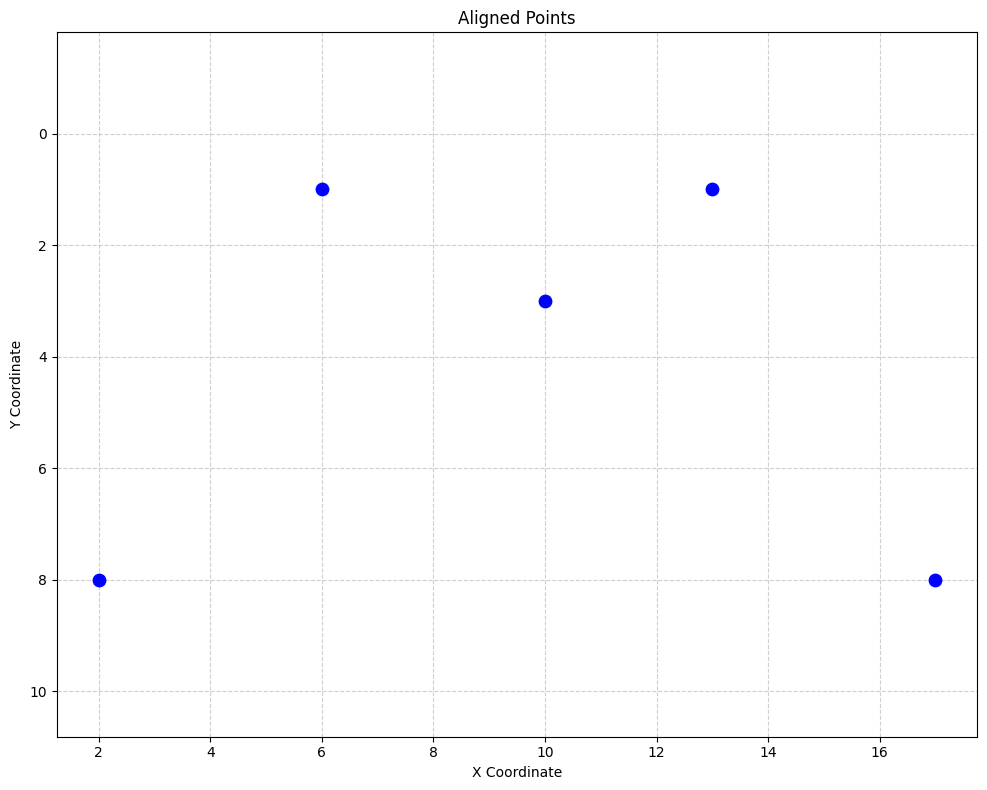

[[2.0, 8.0], [6.0, 1.0], [13.0, 1.0], [17.0, 8.0], [10.0, 3.0]]


In [6]:
from draw_figures import plot_points
from combine_geometry import get_all_intersection_points, get_distinct_points, rescale_points, align_points, force_align_points


points = combined_lines.reshape(-1, 4)[:, :2].tolist()
points.extend(combined_lines.reshape(-1, 4)[:, 2:4].tolist())
intersection_points = get_all_intersection_points(combined_lines)  
points.extend(intersection_points)
plot_points(points, "All Points")
distinct_points = get_distinct_points(points, threshold=60)

rescaled_points = rescale_points(distinct_points)[0]
plot_points(rescaled_points, "Rescaled Points")
aligned_points = force_align_points(rescaled_points)
plot_points(aligned_points, "Aligned Points")
print(aligned_points)

In [7]:
distinc

NameError: name 'distinc' is not defined